In [ ]:
!mamba install pandas numpy openpyxl 
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 50)

'mamba' is not recognized as an internal or external command,
operable program or batch file.


1. Read the supplementary file as raw data.

In [ ]:
import pandas as pd
import pandas.io.excel._openpyxl as pxl
import openpyxl

pxl.import_optional_dependency = lambda *args, **kwargs: openpyxl

xls = pd.ExcelFile("Supplementary File 1.xlsx")
index_df = xls.parse("Index", header=None) # Index sheet contains the table numbers and titles

with pd.option_context("display.max_rows", None,
                       "display.max_columns", None,
                       "display.max_colwidth", None,
                       "display.width", None):
    print(index_df.to_string(index=False, header=False))

 Table S1            The entities retrieved from OMIM associated with epilepsy
 Table S2       The entities retrieved from DisGeNET associating with epilepsy
 Table S3      The entities retrieved from Orphadata associating with epilepsy
 Table S4        The entities retrieved from ClinVar associating with epilepsy
 Table S5       The mapped genes (EAGs) from four phenotype-genotype databases
 Table S6                       The significant GO terms and pathways  of EAGs
 Table S7 The complete edge lists of EAGs from STRING, IntAct and WikiPathways
 Table S8                      The unique nodes in the PMIN and the input heat
 Table S9    The hotNet2 output from PPIN and PMIN by different weight schemes
Table S10                              ASM and their targets from Open Targets


2. To first map the entities to Ensembl IDs and compare the genes from different resources.

In [5]:
omim = pd.read_excel(xls, sheet_name="Table S1")
disgenet = pd.read_excel(xls, sheet_name="Table S2")
orphanet = pd.read_excel(xls, sheet_name="Table S3")
clinvar = pd.read_excel(xls, sheet_name="Table S4")

for df in [omim, disgenet, orphanet, clinvar]:
    df.columns = df.columns.astype(str).str.strip()
print(f"Table S1 / OMIM rows:      {len(omim):,}")
print(f"Table S2 / DisGeNET rows:  {len(disgenet):,}")
print(f"Table S3 / Orphanet rows:  {len(orphanet):,}")
print(f"Table S4 / ClinVar rows:   {len(clinvar):,}")

## Filter OMIM for Phenotype key more than 2
if omim.shape[1] < 7:
    raise ValueError(
        f"Table S1 has only {omim.shape[1]} columns; "
        "it needs at least seven columns for column G." ## Column G is the phenotype key column
    )
omim_filter = pd.to_numeric(
    omim.iloc[:, 6],  
    errors="coerce",
)
omim = omim[omim_filter > 2].copy()
print(f"Table S1 rows after column G > 2 filter: {len(omim):,}")


## Filter DisGeNET for for association score more than 0.4
if disgenet.shape[1] < 6:
    raise ValueError(
        f"Table S2 has only {disgenet.shape[1]} columns; "
        "it needs at least six columns for column F."
    )

disgenet_score = pd.to_numeric(
    disgenet.iloc[:, 5],  # Excel column F
    errors="coerce",
)

n_score_ge_04 = (disgenet_score >= 0.4).sum()

print(f"Table S2 rows with score >= 0.4: {n_score_ge_04:,}")


Table S1 / OMIM rows:      4,730
Table S2 / DisGeNET rows:  602
Table S3 / Orphanet rows:  3,082
Table S4 / ClinVar rows:   541
Table S1 rows after column G > 2 filter: 3,189
Table S2 rows with score >= 0.4: 601


This is to connect to mygene and prepare for mapping.

In [28]:
%pip install mygene
%pip install mygene httpx

import mygene
mg = mygene.MyGeneInfo()
def combine_values(values):
    """Join unique non-empty semicolon-separated values."""
    return "; ".join(sorted({
        item.strip()
        for value in values
        if pd.notna(value)
        for item in str(value).split(";")
        if item.strip()
    }))


def extract_ensembl_ids(value):
    """Return Ensembl gene IDs from a MyGene result."""
    records = value if isinstance(value, list) else [value]
    return "; ".join(sorted({
        str(record["gene"])
        for record in records
        if isinstance(record, dict) and record.get("gene")
    }))


def clean_mim_number(value):
    """Convert Excel-style MIM values such as 607872.0 to 607872."""
    if pd.isna(value):
        return ""
    return re.sub(r"\.0$", "", str(value).strip())


def map_to_ensembl(values, scope, input_column, symbol_column, cleaner=str):
    """Map unique human gene symbols or MIM IDs through MyGene.info."""
    values = sorted({
        cleaned
        for value in values
        if (cleaned := cleaner(value).strip())
    })

    columns = [input_column, symbol_column, "Entrez_ID", "Ensembl_ID"]

    print(f"  Mapping {len(values):,} unique {scope} values...")

    if not values:
        return pd.DataFrame(columns=columns)

    results = mg.querymany(
        values,
        scopes=scope,
        fields="symbol,entrezgene,ensembl.gene",
        species="human",
        verbose=False,
    )

    rows = [
        {
            input_column: cleaner(result.get("query", "")),
            symbol_column: str(result.get("symbol") or ""),
            "Entrez_ID": str(result.get("entrezgene") or ""),
            "Ensembl_ID": extract_ensembl_ids(result.get("ensembl")),
        }
        for result in results
    ]

    return (
        pd.DataFrame(rows, columns=columns)
        .groupby(input_column, as_index=False)
        .agg({column: combine_values for column in columns[1:]})
    )


def map_symbols_to_ensembl(symbols):
    return map_to_ensembl(
        symbols,
        scope="symbol",
        input_column="Input_symbol",
        symbol_column="Official_symbol",
        cleaner=lambda value: str(value) if pd.notna(value) else "",
    )


def map_mim_to_ensembl(mim_values):
    return map_to_ensembl(
        mim_values,
        scope="mim",
        input_column="MIM_number_clean",
        symbol_column="Mapped_GeneSymbol",
        cleaner=clean_mim_number,
    )


mambajs 0.21.4

Process pip requirements ...

Requirement mygene already satisfied.
mambajs 0.21.4

Process pip requirements ...

Requirement mygene already satisfied.
Requirement httpx already satisfied.


In [ ]:
2.2 Compare the overlaping genes across databases.

In [43]:
# Load the already integrated gene comparison table
summary = pd.read_excel(
    xls,
    sheet_name="Table S5",)
summary.columns = summary.columns.astype(str).str.strip()
SOURCES = ["OMIM", "DisGeNET", "Orphanet", "ClinVar"]

# Ensure source-membership columns are True/False
for source in SOURCES:
    summary[source] = (
        summary[source]
        .astype(str)
        .str.strip()
        .str.upper()
        .isin(["TRUE", "1", "YES"])
    )

# Recalculate these columns from the Boolean source columns
summary["Number_of_sources"] = summary[SOURCES].sum(axis=1)

summary["Sources"] = summary.apply(
    lambda row: " + ".join(
        source for source in SOURCES if row[source]
    ),
    axis=1,
)

# Gene sets used by the UpSet and Venn plot cells
source_sets = {
    source: set(
        summary.loc[
            summary[source],
            "Ensembl_ID",
        ]
        .dropna()
        .astype(str)
    )
    for source in SOURCES
}

combination_summary = (
    summary.groupby("Sources", as_index=False)
    .agg(Number_of_genes=("Ensembl_ID", "nunique"))
    .sort_values("Number_of_genes", ascending=False)
)

all_four = summary[
    summary["Number_of_sources"] == 4
].copy()

print(f"Total unique genes: {len(summary):,}")
print(f"Genes in all four sources: {len(all_four):,}")

display(
    combination_summary.style.hide(axis="index")
)

Total unique genes: 2,496
Genes in all four sources: 35


Sources,Number_of_genes
OMIM,1349
OMIM + Orphanet,427
Orphanet,187
DisGeNET,156
OMIM + DisGeNET,150
OMIM + DisGeNET + Orphanet,140
OMIM + DisGeNET + Orphanet + ClinVar,35
OMIM + ClinVar,15
DisGeNET + Orphanet,13
OMIM + DisGeNET + ClinVar,11


2.3 Cross-reference with Gene4Epilepsy v2026-03

In [49]:
GENES4EPILEPSY_FILE = (
    "https://bahlolab.github.io/Genes4Epilepsy/"
    "EpilepsyGenes_v2026-03.tsv"
)

genes4epilepsy = pd.read_csv(
    GENES4EPILEPSY_FILE,
    sep="\t",
    dtype=str,
)
my_ids = set(
    summary["Ensembl_ID"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.split(".")
    .str[0]
)

genes4epilepsy_ids = set(
    genes4epilepsy["Ensemble_ID"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.split(".")
    .str[0]
)

overlap_summary = pd.DataFrame({
    "Category": [
        "Unique to EAGs",
        "Unique to Genes4Epilepsy",
        "Overlapping genes",
    ],
    "Number of genes": [
        len(my_ids - genes4epilepsy_ids),
        len(genes4epilepsy_ids - my_ids),
        len(my_ids & genes4epilepsy_ids),
    ],
})

display(overlap_summary.style.hide(axis="index"))

Category,Number of genes
Unique to EAGs,1516
Unique to Genes4Epilepsy,98
Overlapping genes,980


3. This following is to run ontology terms enrichment and pathway overpresentation analysis from EAGs.

In [62]:
%pip install gprofiler-official
from pathlib import Path
# Cell: extract unique valid Ensembl IDs

import re
import math
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from gprofiler import GProfiler

def extract_ensembl_ids(series):
    genes = set()

    for value in series.dropna():
        for gene in re.split(r"[,;]", str(value)):
            gene = gene.strip().split(".")[0]

            if re.fullmatch(r"ENSG\d+", gene):
                genes.add(gene)

    return sorted(genes)

ensembl_genes = extract_ensembl_ids(
    summary["Ensembl_ID"]
)

print(f"Unique valid Ensembl genes: {len(ensembl_genes):,}")

mambajs 0.21.4

Process pip requirements ...

Requirement gprofiler-official already satisfied.
Unique valid Ensembl genes: 2,496


In [64]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

enrichment = gp.profile(
    organism="hsapiens",
    query=ensembl_genes,
    sources=["GO:BP", "GO:MF", "GO:CC", "WP"],
    significance_threshold_method="fdr",
    user_threshold=0.05,
    no_evidences=False,
)

if enrichment is None:
    enrichment = pd.DataFrame()

print(f"Total significant enrichment terms: {len(enrichment):,}")

Total significant enrichment terms: 4,337


In [80]:
from IPython.display import display, Markdown
def print_top_terms(enrichment, source, title, n=3):  ## Only dispaly top three terms 
    terms = (
        enrichment.loc[
            enrichment["source"] == source,
            ["name", "p_value", "intersection_size", "query_size"]
        ]
        .copy()
    )
    if terms.empty:
        print(f"\n{title}: no significant terms.")
        return
    terms["GeneRatio"] = (
        terms["intersection_size"] / terms["query_size"]
    )
    terms = (
        terms.sort_values("p_value")
        .head(n)
        .rename(columns={
            "name": "Term",
            "p_value": "Adjusted_p_value",
            "intersection_size": "Gene_count",
        })
    )

    display(Markdown(f"**{title}**"))

    display(
        terms[
            [
                "Term",
                "Gene_count",
                "GeneRatio",
                "Adjusted_p_value",
            ]
        ]
        .style
        .format({
            "GeneRatio": "{:.3f}",
            "Adjusted_p_value": "{:.3e}",
        })
        .hide(axis="index")
    )

print_top_terms(enrichment, "GO:BP", "Top three GO Biological Process terms")
print_top_terms(enrichment, "GO:MF", "Top three GO Molecular Function terms")
print_top_terms(enrichment, "GO:CC", "Top three GO Cellular Component terms")
print_top_terms(enrichment, "WP", "Top three WikiPathways pathways")

**Top three GO Biological Process terms**

Term,Gene_count,GeneRatio,Adjusted_p_value
system development,834,0.380,2.745e-102
nervous system development,625,0.285,4.116e-100
multicellular organism development,916,0.417,7.779e-100


**Top three GO Molecular Function terms**

Term,Gene_count,GeneRatio,Adjusted_p_value
catalytic activity,990,0.451,3.270e-66
protein binding,1940,0.884,5.348e-61
heterocyclic compound binding,484,0.221,4.093e-49


**Top three GO Cellular Component terms**

Term,Gene_count,GeneRatio,Adjusted_p_value
cytoplasm,1806,0.815,2.571e-143
organelle membrane,724,0.327,3.758e-73
mitochondrion,440,0.198,4.505e-70


**Top three WikiPathways pathways**

Term,Gene_count,GeneRatio,Adjusted_p_value
Glycosylation and related congenital defects,24,0.016,9.133e-15
Glycosylphosphatidyl inositol anchor pathway,24,0.016,4.961e-14
Metabolic epileptic disorders,50,0.032,1.152e-13


Example to plot top 10  BP terms ranked by adjusted p value.

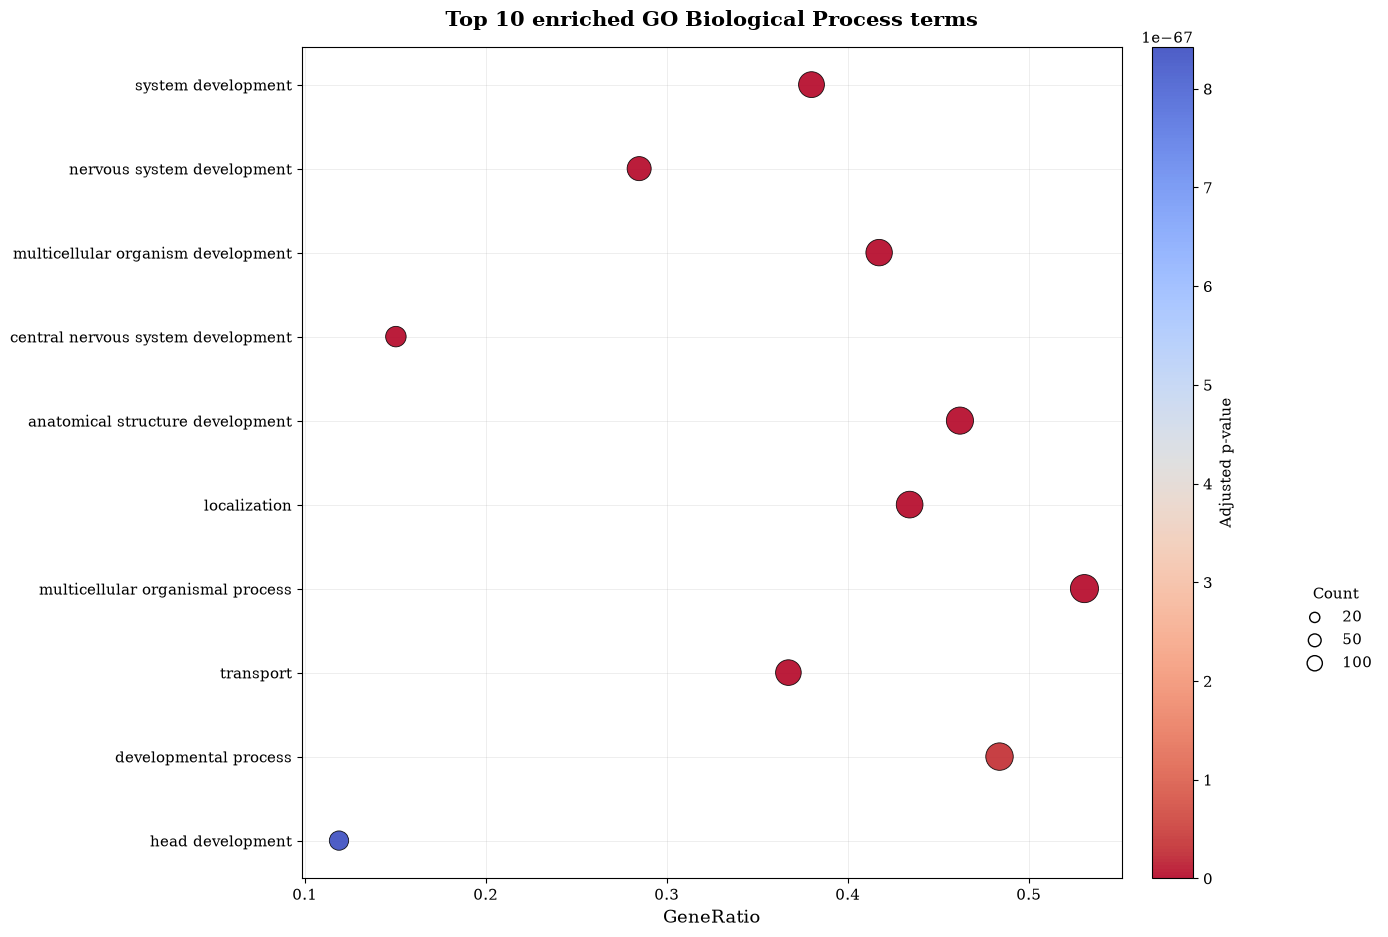

In [71]:
plt.rcParams["font.family"] = "DejaVu Serif"
go_bp = (
    enrichment.loc[
        enrichment["source"] == "GO:BP" ## Only plotting BP terms
    ]
    .copy()
)

go_bp["GeneRatio"] = (
    go_bp["intersection_size"] / go_bp["query_size"]
)

go_bp["Count"] = go_bp["intersection_size"]
go_bp["p_adjust"] = go_bp["p_value"]
enrichment_dotplot(
    go_bp,
    title="Top 10 enriched GO Biological Process terms",
    top_n=10,
    legend_counts=[20, 50, 100],
)

4. Retrival of protein protein interactions (PPIs) and build PPI network

In [ ]:
import pandas as pd
from openpyxl import load_workbook

excel_file = "Copy of Supplementary File 1.xlsx"
workbook = load_workbook(
    excel_file,
    read_only=True,
    data_only=True,
)
worksheet = workbook["Table S7"] ## WP interaction edge list

rows = worksheet.iter_rows(values_only=True)
column_names = next(rows)
wp = pd.DataFrame(
    rows,
    columns=column_names,
)
workbook.close()
wp = wp.dropna(how="all").reset_index(drop=True)
wp.columns = wp.columns.astype(str).str.strip()

print(f"Integrated WP edges: {len(wp):,}")
display(wp.head())

nodes = pd.concat(
    [
        pmi[["source_id", "source_type"]].rename(
            columns={"source_id": "id", "source_type": "type"}
        ),
        pmi[["target_id", "target_type"]].rename(
            columns={"target_id": "id", "target_type": "type"}
        ),
    ],
    ignore_index=True,
)

nodes["id"] = nodes["id"].astype("string").str.strip()
nodes["type"] = nodes["type"].astype("string").str.strip().str.lower()
nodes = nodes.dropna(subset=["id"])
nodes = nodes[nodes["id"].ne("")]

print(f"Total unique source + target IDs: {nodes['id'].nunique():,}")
print("\nUnique IDs by type:")
print(nodes.groupby("type")["id"].nunique().to_string())

Integrated WP edges: 11,955


,source_id,source_label,source_type,source_ensembl,target_id,target_label,target_type,target_ensembl,interaction_category,database_count,source_database,pathway_id,pathway_count,interaction_types
0,ENSG00000000419,DPM1,protein,ENSG00000000419,ENSG00000136908,DPM2,protein,ENSG00000136908,Protein–protein,1,WikiPathways,WP4521,1,Stimulation
1,ENSG00000000971,CFH,protein,ENSG00000000971,ENSG00000005961,ITGA2B,protein,ENSG00000005961,Protein–protein,1,WikiPathways,WP2806,1,Binding
2,ENSG00000000971,CFH,protein,ENSG00000000971,ENSG00000029559,IBSP,protein,ENSG00000029559,Protein–protein,1,WikiPathways,WP2806,1,Binding
3,ENSG00000000971,CFH,protein,ENSG00000000971,ENSG00000118785,SPP1,protein,ENSG00000118785,Protein–protein,1,WikiPathways,WP2806,1,Binding
4,ENSG00000000971,CFH,protein,ENSG00000000971,ENSG00000125730,C3,protein,ENSG00000125730,Protein–protein,1,WikiPathways,WP2806,1,Binding


Total unique source + target IDs: 7,448

Unique IDs by type:
type
metabolite    4331
protein       3117


In [52]:
import networkx as nx

# Build the undirected network.
edges = wp[["source_id", "target_id"]].apply(
    lambda s: s.astype("string").str.strip()
).replace("", pd.NA).dropna()

edges = edges[edges["source_id"] != edges["target_id"]]
G = nx.from_pandas_edgelist(edges, "source_id", "target_id")

# Collect node identifiers, labels, and types.
info = pd.concat([
    wp[[f"{side}_id", f"{side}_label", f"{side}_type"]]
    .set_axis(["node_id", "label", "type"], axis=1)
    for side in ["source", "target"]
], ignore_index=True)

for col in info.columns:
    info[col] = info[col].astype("string").str.strip()

info["type"] = info["type"].str.lower()
info = info.dropna(subset=["node_id"])

# Preserve distinct labels/types associated with each identifier.
info = info.groupby("node_id").agg(
    lambda s: "; ".join(sorted(set(s.dropna()) - {""}))
)

ranking = (
    pd.DataFrame(G.degree(), columns=["node_id", "degree"])
    .join(info, on="node_id")
    .sort_values(["degree", "node_id"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Top 10 highest-degree nodes:")
display(ranking[["node_id", "label", "type", "degree"]].head(10))

# Adjust these sets if Table S7 uses different type names.
protein_types = {"gene", "protein", "gene product", "gene_product", "geneproduct"}
metabolite_types = {"metabolite", "compound", "small molecule", "small_molecule"}

for category, accepted_types in [
    ("protein/gene product", protein_types),
    ("metabolite", metabolite_types),
]:
    subset = ranking[
        ranking["type"].apply(
            lambda value: bool(set(value.split("; ")) & accepted_types)
        )
    ]

    print(f"\nHighest-degree {category}(s):")
    if subset.empty:
        print("No matching type found. Available types:", info["type"].unique())
    else:
        # Show all nodes tied for the highest degree in this category.
        display(subset.loc[
            subset["degree"].eq(subset["degree"].max()),
            ["node_id", "label", "type", "degree"]
        ])

Top 10 highest-degree nodes:


,node_id,label,type,degree
0,ENSG00000142208,AKT1,protein,122
1,ENSG00000141510,TP53,protein,106
2,ENSG00000112062,MAPK14,protein,73
3,ENSG00000118260,CREB1,protein,68
4,ENSG00000168610,STAT3,protein,68
5,ENSG00000168036,CTNNB1,protein,65
6,ENSG00000109320,NFKB1,protein,63
7,ENSG00000100030,MAPK1,protein,62
8,ENSG00000197122,SRC,protein,59
9,ENSG00000128052,KDR,protein,56



Highest-degree protein/gene product(s):


,node_id,label,type,degree
0,ENSG00000142208,AKT1,protein,122



Highest-degree metabolite(s):


,node_id,label,type,degree
10,chebi:CHEBI:26523,MtROS;ROS;ROS production;Reactive Oxygen Spec...,metabolite,55


In [53]:
top100_genes = ranking[
    ranking["type"].fillna("").apply(
        lambda value: bool(set(value.split("; ")) & protein_types)
    )
].head(100)

print("\nTop 100 highest-degree genes/proteins:")
print(top100_genes["label"].to_string(index=False))


Top 100 highest-degree genes/proteins:
     AKT1
     TP53
   MAPK14
    CREB1
    STAT3
   CTNNB1
    NFKB1
    MAPK1
      SRC
      KDR
    HDAC6
      MYC
    MAPK8
     RAC1
      ATM
    MAPK3
     PTK2
     MTOR
     JAK1
     RHOA
     EGFR
      ATR
     JAK2
     GRB2
   PIK3R1
    TRAF6
      TNF
    PLCG1
    PRKCA
    TGFB1
     RAF1
    CDC42
    GSK3B
    UNC5B
    STAT1
     KRAS
    CASP3
   PTPN11
    PPARG
   PRKAA2
    BRCA1
   PIK3CA
      JUN
      SHH
     RELA
      SP1
      RET
   MAP3K1
     BCL2
    CEBPB
   PRKACA
   STAT5A
   NOTCH1
     HRAS
    SMAD2
      FYN
     ESR1
    SOX10
   MAP3K7
     SHC1
     CHUK
     IRS1
     GNAS
     E2F1
    IKBKB
     PTEN
  PITPNM3
 PPARGC1A
    VEGFA
     SOX9
    CCND1
    MYD88
    HIF1A
    NTRK2
  TACSTD2
    CASP8
   IL18R1
    RAP1A
   CDKN1A
       C3
    FOXA2
    SMAD4
     GNAQ
     BRAF
       AR
    SMAD1
    SIRT1
  RPS6KB1
    PTK2B
    TRAF2
    ITGB1
    FOXO1
     TSHR
    SMAD3
   STAT5B
      BAX


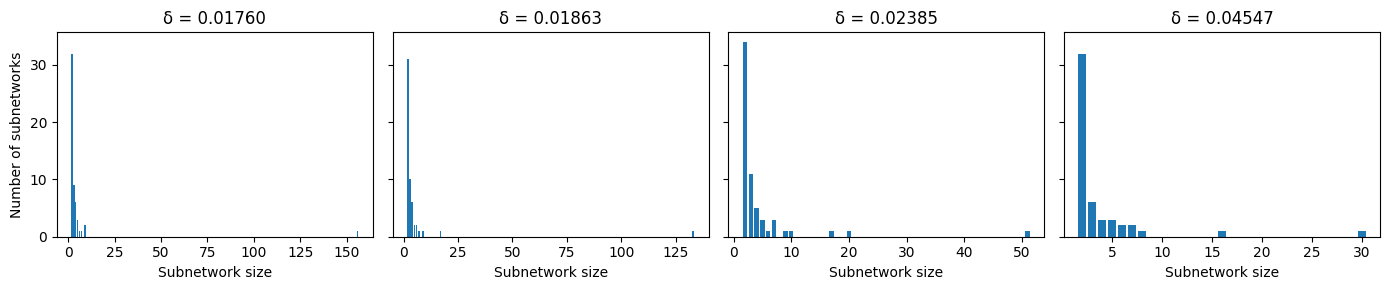

In [ ]:
import pandas as pd
from openpyxl import load_workbook

excel_file = "Copy of Supplementary File 1.xlsx"
workbook = load_workbook(
    excel_file,
    read_only=True,
    data_only=True,
)
worksheet = workbook["Table S8"] ## HotNet2 Ouput 
import matplotlib.pyplot as plt

rows = worksheet.iter_rows(values_only=True)
df = pd.DataFrame(rows, columns=next(rows)).dropna(how="all")
workbook.close()
df.columns = df.columns.astype(str).str.strip()

df["delta"] = pd.to_numeric(df["delta"], errors="coerce")
df["size"] = pd.to_numeric(df["size"], errors="coerce")
df = df.dropna(subset=["delta", "size"])

deltas = sorted(df["delta"].unique())
fig, axes = plt.subplots(
    1, len(deltas), figsize=(14, 3), sharey=True, squeeze=False
)

for ax, delta in zip(axes.flat, deltas):
    counts = df.loc[df["delta"] == delta, "size"].value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"δ = {delta:.5f}")
    ax.set_xlabel("Subnetwork size")

axes[0, 0].set_ylabel("Number of subnetworks")
plt.tight_layout()
plt.show()

Network topology: which node has the highest degree?

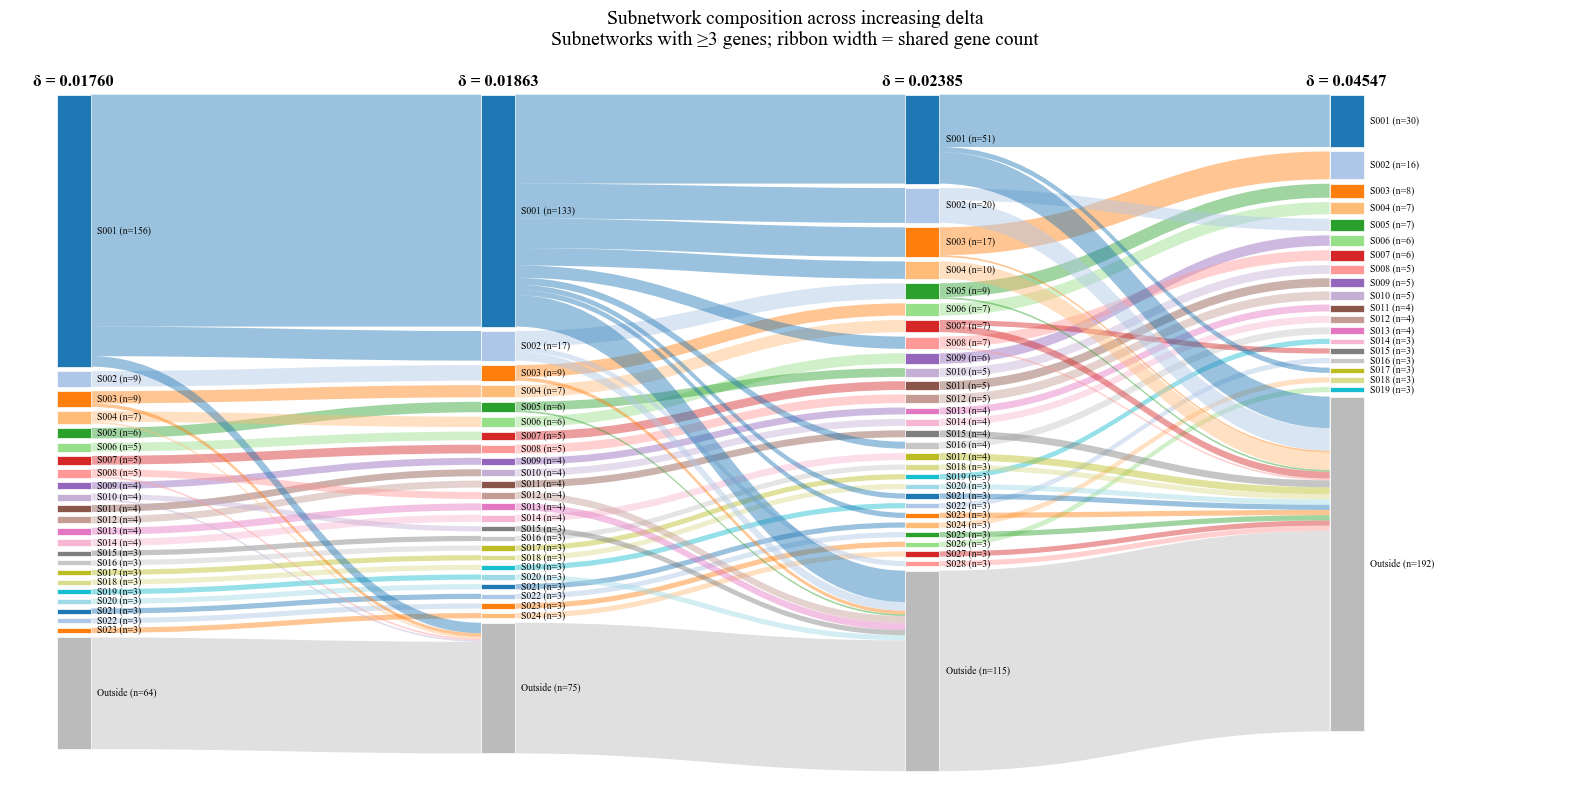

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle

# Load Table S8 (HotNet2 output)
df = pd.read_excel("Copy of Supplementary File 1.xlsx", sheet_name="Table S8")
df.columns = df.columns.astype(str).str.strip()
df = df.dropna(subset=["delta", "subnetwork_index", "size", "genes"]).copy()

for col in ["delta", "subnetwork_index", "size"]:
    df[col] = pd.to_numeric(df[col], errors="raise")
df["gene_set"] = df["genes"].apply(
    lambda value: {g.strip() for g in str(value).split(";") if g.strip()}
)

min_nodes = 3
deltas = sorted(df["delta"].unique())
outside = "Outside"

if len(deltas) < 2:
    raise ValueError("At least two delta values are required.")

# Use a fixed gene universe to conserve flow across all columns.
universe = set().union(*df["gene_set"])
modules, orders = {}, {}

for delta in deltas:
    rows = df[df["delta"] == delta]
    assigned = set()
    modules[delta] = {}

    for _, row in rows.iterrows():
        genes = row["gene_set"]
        if len(genes) != row["size"]:
            raise ValueError(f"Gene count differs from size at delta {delta}.")
        if assigned & genes:
            raise ValueError(f"A gene belongs to multiple subnetworks at delta {delta}.")
        assigned.update(genes)

        if len(genes) >= min_nodes:
            name = f"S{int(row['subnetwork_index']):03d}"
            if name in modules[delta]:
                raise ValueError(f"Duplicate subnetwork index at delta {delta}.")
            modules[delta][name] = genes

    displayed = set().union(set(), *modules[delta].values())
    modules[delta][outside] = universe - displayed

    orders[delta] = sorted(
        [name for name in modules[delta] if name != outside],
        key=lambda name: (-len(modules[delta][name]), name)
    )
    if modules[delta][outside]:
        orders[delta].append(outside)

# Position blocks; their heights equal gene counts.
gap = max(1, len(universe) * 0.008)
height = len(universe) + max(map(len, orders.values())) * gap
positions, colors = {}, {}
palette = plt.get_cmap("tab20")

for delta in deltas:
    positions[delta], colors[delta] = {}, {}
    top = height

    for i, name in enumerate(orders[delta]):
        size = len(modules[delta][name])
        positions[delta][name] = (top - size, top)
        colors[delta][name] = (
            "#BBBBBB" if name == outside else palette(i % palette.N)
        )
        top -= size + gap

fig, ax = plt.subplots(
    figsize=(16, max(8, 0.25 * max(map(len, orders.values()))))
)
xs = np.arange(len(deltas))
width = 0.08

# Connect adjacent delta columns using gene-set intersections.
for step, (left, right) in enumerate(zip(deltas[:-1], deltas[1:])):
    left_offset = {n: positions[left][n][0] for n in orders[left]}
    right_offset = {n: positions[right][n][0] for n in orders[right]}

    # Reverse traversal stacks ribbons consistently from bottom to top.
    for source in reversed(orders[left]):
        for target in reversed(orders[right]):
            count = len(modules[left][source] & modules[right][target])
            if count == 0:
                continue

            y0, z0 = left_offset[source], right_offset[target]
            y1, z1 = y0 + count, z0 + count
            left_offset[source], right_offset[target] = y1, z1

            x0, x1 = xs[step] + width / 2, xs[step + 1] - width / 2
            bend = (x1 - x0) * 0.45

            vertices = [
                (x0, y0), (x0 + bend, y0), (x1 - bend, z0), (x1, z0),
                (x1, z1), (x1 - bend, z1), (x0 + bend, y1), (x0, y1),
                (x0, y0)
            ]
            codes = [
                Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
                Path.CLOSEPOLY
            ]

            ax.add_patch(PathPatch(
                Path(vertices, codes),
                facecolor=colors[left][source],
                edgecolor="none", alpha=0.45
            ))
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["pdf.fonttype"] = 42  # Embed TrueType fonts in the PDF
# Draw subnetwork blocks and labels.
for x, delta in zip(xs, deltas):
    for name in orders[delta]:
        bottom, top = positions[delta][name]

        ax.add_patch(Rectangle(
            (x - width / 2, bottom), width, top - bottom,
            facecolor=colors[delta][name],
            edgecolor="white", linewidth=0.5, zorder=3
        ))
        ax.text(
            x + width / 2 + 0.015, (bottom + top) / 2,
            f"{name} (n={int(top - bottom)})",
            fontsize=7, va="center", zorder=4
        )

    ax.text(
        x, height + gap * 2, f"δ = {delta:.5f}",
        ha="center", fontsize=12, fontweight="bold"
    )

ax.set_xlim(-0.15, len(deltas) - 1 + 0.55)
ax.set_ylim(-gap, height + gap * 5)
ax.axis("off")
ax.set_title(
    f"Subnetwork composition across increasing delta\n"
    f"Subnetworks with ≥{min_nodes} genes; ribbon width = shared gene count",
    fontsize=14, pad=20
)

plt.tight_layout()
fig.savefig("delta_alluvial.png", dpi=300, bbox_inches="tight")
fig.savefig("delta_alluvial.pdf", bbox_inches="tight")
plt.show()
fig.savefig("delta_alluvial.png", dpi=1200, bbox_inches="tight")

Connect to cytoscape for visualization

In [ ]:
%pip install py4cytoscape openpyxl  ## make sure Cytoscape is open

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\P70094486\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [51]:
# Run once if needed:
# %pip install py4cytoscape openpyxl

import re
import numpy as np
import pandas as pd
import py4cytoscape as p4c

excel_file = "Copy of Supplementary File 1.xlsx"

tables = pd.read_excel(
    excel_file, sheet_name=["Table S5", "Table S7", "Table S8"]
)
for table in tables.values():
    table.columns = table.columns.astype(str).str.strip()

attributes = tables["Table S5"].copy()
wp = tables["Table S7"].copy()
modules = tables["Table S8"].copy()

def gene_ids(value):
    return sorted(set(re.findall(r"ENSG\d+", str(value)))) if pd.notna(value) else []

# 1. Select subnetworks at the highest delta.
for col in ["delta", "subnetwork_index", "size"]:
    modules[col] = pd.to_numeric(modules[col], errors="raise")

selected_delta = modules["delta"].max()
min_size = 2

modules = modules[
    np.isclose(modules["delta"], selected_delta, rtol=0, atol=1e-12)
    & (modules["size"] >= min_size)
].copy()

modules["id"] = modules["genes"].apply(gene_ids)

if modules.empty:
    raise ValueError("No subnetworks match the selected delta and size.")
if not modules["id"].str.len().eq(modules["size"]).all():
    raise ValueError("Gene lists do not match the reported subnetwork sizes.")

nodes = (
    modules[["id", "subnetwork_index", "size", "delta"]]
    .explode("id")
    .rename(columns={"size": "subnetwork_size"})
    .reset_index(drop=True)
)

if nodes["id"].duplicated().any():
    raise ValueError("A gene appears in multiple selected subnetworks.")

# 2. Attach Table S5 attributes using Ensembl identifiers.
attribute_cols = [
    "Ensembl_ID", "Gene_symbol", "OMIM", "DisGeNET",
    "Orphanet", "ClinVar", "Number_of_sources", "Sources"
]
attributes = attributes[attribute_cols].copy()
attributes["id"] = attributes["Ensembl_ID"].apply(gene_ids)
attributes = attributes.explode("id").dropna(subset=["id"]).drop_duplicates()

if attributes["id"].duplicated().any():
    raise ValueError("Table S5 contains conflicting rows for the same Ensembl ID.")

nodes = nodes.merge(attributes, on="id", how="left", validate="one_to_one")

# Use the gene symbol as the label; fall back to ID if unavailable.
nodes["Gene_symbol"] = nodes["Gene_symbol"].astype("string").str.strip()
nodes["label"] = nodes["Gene_symbol"].replace("", pd.NA).fillna(nodes["id"])

print(f"Genes without a symbol: {nodes['label'].eq(nodes['id']).sum()}")

# 3. Map Table S7 endpoints to Ensembl identifiers.
for side in ["source", "target"]:
    mapped = wp[f"{side}_ensembl"].apply(gene_ids)
    fallback = wp[f"{side}_id"].apply(gene_ids)
    mapped = mapped.where(mapped.str.len().gt(0), fallback)

    if mapped.str.len().gt(1).any():
        raise ValueError(f"Resolve multiple Ensembl IDs for {side} endpoints.")

    wp[side] = mapped.str[0]

# Retain WP interactions within each selected subnetwork.
membership = nodes.set_index("id")["subnetwork_index"]

edges = wp[["source", "target"]].dropna().copy()
edges = edges[
    edges["source"].isin(membership.index)
    & edges["target"].isin(membership.index)
    & edges["source"].ne(edges["target"])
]
edges = edges[
    edges["source"].map(membership)
    == edges["target"].map(membership)
]

# Collapse duplicate undirected edges.
edges[["source", "target"]] = np.sort(
    edges[["source", "target"]].to_numpy(), axis=1
)
edges = edges.drop_duplicates().reset_index(drop=True)
edges["interaction"] = "WP interaction"

# Convert missing values to None for import, preserving numeric attributes.
nodes = nodes.astype(object).where(nodes.notna(), None)

# 4. Create the Cytoscape network and display gene symbols.
p4c.cytoscape_ping()

network_suid = p4c.create_network_from_data_frames(
    nodes=nodes,
    edges=edges,
    title=f"HotNet2 modules — delta {selected_delta:.5f}",
    collection="HotNet2"
)

# Explicitly assign each node's displayed label.
p4c.set_node_label_bypass(
    nodes["id"].tolist(),
    nodes["label"].tolist(),
    network=network_suid
)

print(f"Imported {len(nodes)} genes and {len(edges)} WP edges.")

Genes without a symbol: 0
You are connected to Cytoscape!
Applying default style...
Applying preferred layout
Imported 189 genes and 142 WP edges.


In [58]:
# Use the network created by your original script.
net = "HotNet2 modules — delta 0.04547"  # Replace with your actual network name

# 1. Collect interaction types for each undirected gene pair.
types = wp[["source", "target", "interaction_types"]].dropna(
    subset=["source", "target"]
).copy()

types["pair"] = [
    tuple(sorted((source, target)))
    for source, target in zip(types["source"], types["target"])
]

type_lookup = types.groupby("pair")["interaction_types"].agg(
    lambda values: "; ".join(sorted({
        str(value).strip()
        for value in values.dropna()
        if str(value).strip()
    }))
)

# 2. Read the existing Cytoscape edge names.
cy_edges = p4c.get_table_columns(
    table="edge",
    columns=["name"],
    network=net
)

# The original import names edges using their Ensembl endpoints:
# ENSG... (WP interaction) ENSG...
def edge_pair(name):
    ids = re.findall(r"ENSG\d+", str(name))
    return tuple(sorted(ids)) if len(ids) == 2 else None

cy_edges["pair"] = cy_edges["name"].apply(edge_pair)
cy_edges["interaction_types"] = cy_edges["pair"].map(type_lookup)

# Only update edges with a nonempty annotation.
updates = cy_edges.loc[
    cy_edges["interaction_types"].fillna("").ne(""),
    ["name", "interaction_types"]
].copy()

if updates.empty:
    raise ValueError(
        "No matching interaction types found. "
        "Check wp and the existing Cytoscape edge names."
    )

# 3. Add the interaction_types column to the existing edge table.
p4c.load_table_data(
    updates,
    data_key_column="name",
    table="edge",
    table_key_column="name",
    network=net
)

print(f"Added interaction types to {len(updates)} of {len(cy_edges)} edges.")

Added interaction types to 101 of 101 edges.


Which subnetworks are connected by one edge?

Which subnetworks are connected by one node?

In [46]:
import re
import numpy as np
import pandas as pd
from collections import defaultdict

excel_file = "Copy of Supplementary File 1.xlsx"
min_size = 2

# Load edges and HotNet2 subnetworks.
tables = pd.read_excel(excel_file, sheet_name=["Table S7", "Table S8"])
wp = tables["Table S7"].copy()
modules = tables["Table S8"].copy()

for table in [wp, modules]:
    table.columns = table.columns.astype(str).str.strip()

def gene_ids(value):
    if pd.isna(value):
        return []
    return sorted(set(re.findall(r"ENSG\d+", str(value))))

# Select the highest delta.
for col in ["delta", "subnetwork_index", "size"]:
    modules[col] = pd.to_numeric(modules[col], errors="raise")

selected_delta = modules["delta"].max()
modules = modules[
    np.isclose(modules["delta"], selected_delta, rtol=0, atol=1e-12)
    & (modules["size"] >= min_size)
].copy()

if modules.empty:
    raise ValueError("No subnetworks match the selected delta and size.")

modules["gene_set"] = modules["genes"].apply(lambda v: set(gene_ids(v)))

if not modules["gene_set"].map(len).eq(modules["size"]).all():
    raise ValueError("Gene lists do not match the reported subnetwork sizes.")

if modules["subnetwork_index"].duplicated().any():
    raise ValueError("Duplicate subnetwork indices at the selected delta.")

subnetworks = {
    int(row.subnetwork_index): row.gene_set
    for row in modules.itertuples()
}

# Map WP endpoints to Ensembl IDs.
for side in ["source", "target"]:
    id_col = f"{side}_id"
    ensembl_col = f"{side}_ensembl"

    fallback = wp[id_col].apply(gene_ids)
    mapped = (
        wp[ensembl_col].apply(gene_ids)
        if ensembl_col in wp.columns else fallback
    )
    mapped = mapped.where(mapped.str.len().gt(0), fallback)

    if mapped.str.len().gt(1).any():
        raise ValueError(
            f"Some {side} endpoints map to multiple Ensembl IDs. "
            "Resolve these mappings first."
        )

    wp[side] = mapped.str[0]

# Get connector labels exclusively from Table S7.
labels = pd.concat([
    wp[["source", "source_label"]].set_axis(["id", "symbol"], axis=1),
    wp[["target", "target_label"]].set_axis(["id", "symbol"], axis=1),
], ignore_index=True).dropna()

labels["symbol"] = labels["symbol"].astype(str).str.strip()
labels = labels[labels["symbol"].ne("")]

symbols = labels.groupby("id")["symbol"].agg(
    lambda values: "; ".join(sorted(set(values)))
).to_dict()

# Build an undirected adjacency map from all mapped WP edges.
adjacency = defaultdict(set)

for source, target in (
    wp[["source", "target"]].dropna().itertuples(index=False, name=None)
):
    if source != target:
        adjacency[source].add(target)
        adjacency[target].add(source)

# Find external first neighbours of each subnetwork.
connector_subnetworks = defaultdict(set)

for index, genes in subnetworks.items():
    neighbours = set()
    for gene in genes:
        neighbours.update(adjacency.get(gene, set()))

    neighbours -= genes

    for connector in neighbours:
        connector_subnetworks[connector].add(index)

# One row per connector shared by at least two subnetworks.
connectors = pd.DataFrame([
    {
        "connector_id": gene,
        "connector_symbol": symbols.get(gene, "Not available"),
        "connecting_subnetworks": "; ".join(map(str, sorted(indices))),
        "number_of_subnetworks": len(indices),
    }
    for gene, indices in connector_subnetworks.items()
    if len(indices) >= 2
], columns=[
    "connector_id", "connector_symbol",
    "connecting_subnetworks", "number_of_subnetworks"
]).sort_values(
    ["number_of_subnetworks", "connector_id"],
    ascending=[False, True]
).reset_index(drop=True)

print(f"Selected delta: {selected_delta:.8f}")
print(f"Subnetworks: {len(subnetworks)}")
print(f"Shared connector genes: {len(connectors)}")
display(connectors)


Selected delta: 0.04547249
Subnetworks: 51
Shared connector genes: 44


,connector_id,connector_symbol,connecting_subnetworks,number_of_subnetworks
0,ENSG00000118260,CREB1,1; 5; 11; 12; 41,5
1,ENSG00000141510,TP53,1; 18; 34; 40,4
2,ENSG00000010810,FYN,2; 7; 22,3
3,ENSG00000070808,CAMK2A,1; 2; 34,3
4,ENSG00000106571,GLI3,1; 7; 31,3
5,ENSG00000110931,CAMKK2,5; 11; 30,3
6,ENSG00000115415,STAT1,1; 15; 48,3
7,ENSG00000124813,RUNX2,7; 11; 27,3
8,ENSG00000160255,ITGB2,22; 43; 50,3
9,ENSG00000162409,PRKAA2,2; 5; 30,3


In [42]:
# Run once:
%pip install gprofiler-official openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\P70094486\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [43]:
import re
import numpy as np
import pandas as pd
from gprofiler import GProfiler

excel_file = "Copy of Supplementary File 1.xlsx"
top_n = 1       # Increase to print more terms per subnetwork.
min_size = 2
alpha = 0.05

# Load HotNet2 subnetworks.
modules = pd.read_excel(excel_file, sheet_name="Table S8")
modules.columns = modules.columns.astype(str).str.strip()
modules = modules.dropna(
    subset=["delta", "subnetwork_index", "size", "genes"]
).copy()

for col in ["delta", "subnetwork_index", "size"]:
    modules[col] = pd.to_numeric(modules[col], errors="raise")

selected_delta = modules["delta"].max()
modules = modules[
    np.isclose(modules["delta"], selected_delta, rtol=0, atol=1e-12)
    & (modules["size"] >= min_size)
].sort_values("subnetwork_index")

if modules.empty:
    raise ValueError("No subnetworks match the selected delta and size.")

if modules["subnetwork_index"].duplicated().any():
    raise ValueError("Duplicate subnetwork indices at the selected delta.")

# One query per subnetwork.
queries = {}
for row in modules.itertuples():
    genes = sorted(set(re.findall(r"ENSG\d+", str(row.genes))))
    if len(genes) != row.size:
        raise ValueError(f"Gene count mismatch in subnetwork {row.subnetwork_index}.")
    queries[f"SN_{int(row.subnetwork_index)}"] = genes

# Running this sends gene identifiers to the g:Profiler web service.
gp = GProfiler(return_dataframe=True)

enrichment = gp.profile(
    organism="hsapiens",
    query=queries,
    sources=["GO:BP"],
    ordered=False,
    significance_threshold_method="fdr",
    user_threshold=alpha,
    all_results=False,
    domain_scope="annotated"
)

# Report the top significant term(s); retain subnetworks with no hits.
records = []

for query in queries:
    hits = (
        enrichment.loc[enrichment["query"].eq(query)]
        .sort_values(["p_value", "native"])
        .head(top_n)
        if enrichment is not None and not enrichment.empty
        else pd.DataFrame()
    )

    index = int(query.removeprefix("SN_"))

    if hits.empty:
        records.append({
            "subnetwork_index": index,
            "GO_ID": "",
            "BP_term": "No significant BP term",
            "padj": np.nan,
        })
    else:
        for hit in hits.itertuples():
            records.append({
                "subnetwork_index": index,
                "GO_ID": hit.native,
                "BP_term": hit.name,
                "padj": hit.p_value,
            })

results = pd.DataFrame(records)

print(results.to_string(
    index=False,
    float_format=lambda value: f"{value:.3e}",
    na_rep="—"
))

# Optional export:
# results.to_csv("subnetwork_GO_BP_top_terms.csv", index=False)

 subnetwork_index      GO_ID                                                                BP_term      padj
                1 GO:0007399                                             nervous system development 1.977e-12
                2 GO:0086001                                   cardiac muscle cell action potential 1.347e-18
                3 GO:0006325                                                 chromatin organization 6.412e-08
                4 GO:0021987                                            cerebral cortex development 9.964e-08
                5 GO:0031929                                                          TOR signaling 6.136e-05
                6 GO:0007268                                         chemical synaptic transmission 2.589e-05
                7 GO:0001708                                                cell fate specification 1.343e-06
                8 GO:0044782                                                    cilium organization 9.737e-07
          